# CS406 -- Digital Image Processing: Class Activity 6 (CA-6)
## Frequency-Domain Image Filtering

**School of Systems and Technology (SST), Department of Computer Science, UMT**

**Semester:** Summer 2026 &nbsp;|&nbsp; **Instructor:** Dr. Jameel Ahmad &nbsp;|&nbsp; **Total Marks:** 2%

**Group:** CA-6 &nbsp;|&nbsp; **Submission Date:** 23/09/2026 (brief due date: September 10, 2026)

| Student | UMT ID |
|---|---|
| Muhammad Umer | F2023266912 |
| Haseeb Ullah | F20232661009 |

*(CA-6 asks for groups of 4. Our group has 2 active members; both worked through every task together and jointly authored every section, so this notebook has no per-task role split -- each member can independently explain every task, as required.)*

## 1. Introduction

Frequency-domain filtering is a fundamental technique in digital image processing that operates on the Fourier transform of an image. By transforming an image from the spatial domain to the frequency domain, we can selectively modify specific frequency components to achieve desired effects such as smoothing, sharpening, or noise reduction.

This notebook presents the implementation and analysis of ideal, Gaussian, and Butterworth low-pass and high-pass filters, as well as high-frequency emphasis (HFE) filtering. The experiments are conducted using Python with NumPy, Matplotlib, and scikit-image on the standard "cameraman" test image.

### Setup and shared helper functions

All filters share the same three building blocks: a **distance matrix** $D(u,v)$ giving each frequency-domain coordinate's distance from the origin, an **`apply_filter`** routine that multiplies a filter $H(u,v)$ onto the image's FFT and inverts it back to the spatial domain, and a **`show_images`** helper for consistent side-by-side display.

In [1]:
%matplotlib inline
import os
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_float
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.util import random_noise

plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titlesize'] = 10

RESULTS_DIR = './results'
os.makedirs(RESULTS_DIR, exist_ok=True)


def save_fig(fig, name):
    path = os.path.join(RESULTS_DIR, name)
    fig.savefig(path, bbox_inches='tight', dpi=150)
    print(f"Saved: {path}")


def show_images(images, titles, cmap='gray', figsize=(14, 4), save_as=None):
    fig, axes = plt.subplots(1, len(images), figsize=figsize)
    axes = np.atleast_1d(axes)
    for ax, img, title in zip(axes, images, titles):
        ax.imshow(img, cmap=cmap)
        ax.set_title(title, fontsize=10)
        ax.axis('off')
    plt.tight_layout()
    if save_as:
        save_fig(fig, save_as)
    plt.show()


def compute_fft(image):
    F = np.fft.fft2(image)
    F_shift = np.fft.fftshift(F)
    magnitude = np.log1p(np.abs(F_shift))
    return F, F_shift, magnitude


def distance_matrix(M, N):
    u = np.fft.fftfreq(M) * M
    v = np.fft.fftfreq(N) * N
    V, U = np.meshgrid(v, u)
    return np.sqrt(U ** 2 + V ** 2)


def apply_filter(image, H):
    F = np.fft.fft2(image)
    G = H * F
    g = np.real(np.fft.ifft2(G))
    return np.clip(g, 0, 1)


# --- Low-pass filters ---------------------------------------------------------------
def ideal_lpf(D, D0):
    return (D <= D0).astype(float)


def gaussian_lpf(D, sigma):
    return np.exp(-(D ** 2) / (2 * sigma ** 2))


def butterworth_lpf(D, D0, n):
    return 1 / (1 + (D / D0) ** (2 * n))


# --- High-pass filters (complements of the LPFs) -------------------------------------
def ideal_hpf(D, D0):
    return 1 - ideal_lpf(D, D0)


def gaussian_hpf(D, sigma):
    return 1 - gaussian_lpf(D, sigma)


def butterworth_hpf(D, D0, n):
    H = np.zeros_like(D)
    mask = D > 0
    H[mask] = 1 / (1 + (D0 / D[mask]) ** (2 * n))
    return H


# --- High-frequency emphasis ----------------------------------------------------------
def hfe_filter(H_hpf, a, b):
    return a + b * H_hpf


# Load the standard test image
image = img_as_float(data.camera())
M, N = image.shape
D = distance_matrix(M, N)
print(f'Image: skimage.data.camera(), shape={image.shape}, dtype={image.dtype}, range=[{image.min():.2f}, {image.max():.2f}]')

Image: skimage.data.camera(), shape=(512, 512), dtype=float64, range=[0.00, 1.00]


---
## 2. Task 1: Visualising the 2D Fourier Transform

### 2.1 Implementation

The 2D Discrete Fourier Transform (DFT) is computed with NumPy's `fft2`. `fftshift` centres the zero-frequency (DC) component for visualisation. The log-magnitude spectrum is computed as $S(u,v) = \log(1 + |F(u,v)|)$, which compresses the huge dynamic range of $|F|$ so that both faint high-frequency detail and the dominant low-frequency content are visible in the same image.

Saved: ./results\task1_results.png


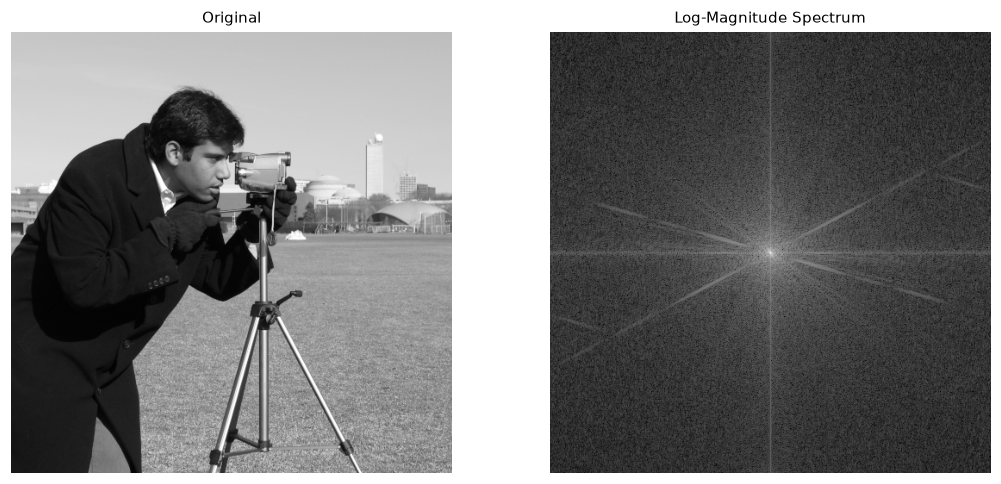

DC component F(0,0) = 132676.4510+0.0000j
Mean pixel value * M*N = 132676.4510
Mean pixel value (recovered from DC) = 0.506120 vs. image.mean() = 0.506120


In [2]:
F, F_shift, mag_spectrum = compute_fft(image)

show_images([image, mag_spectrum], ['Original', 'Log-Magnitude Spectrum'],
            figsize=(10, 4.5), save_as='task1_results.png')

dc = F[0, 0]
print(f'DC component F(0,0) = {dc:.4f}')
print(f'Mean pixel value * M*N = {image.mean() * M * N:.4f}')
print(f'Mean pixel value (recovered from DC) = {(dc.real / (M * N)):.6f} vs. image.mean() = {image.mean():.6f}')

Saved: ./results\task1_dc_marked.png


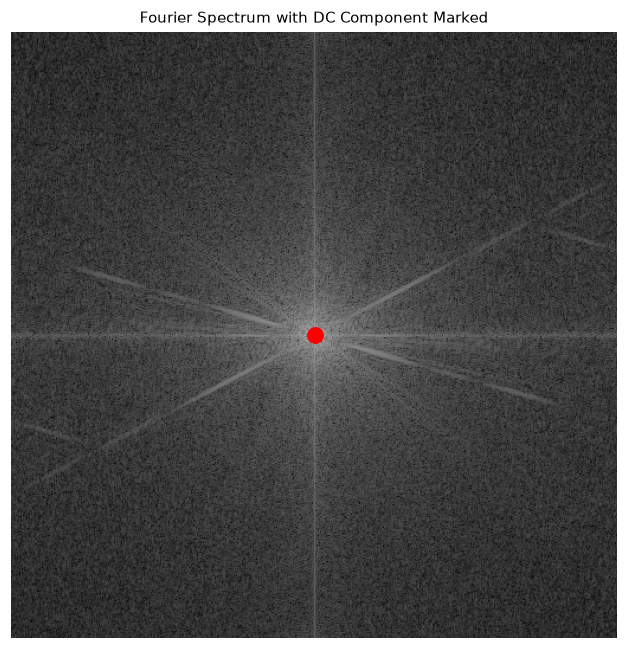

In [3]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(mag_spectrum, cmap='gray')
ax.scatter(F_shift.shape[1] // 2, F_shift.shape[0] // 2, c='red', s=100, marker='o')
ax.set_title('Fourier Spectrum with DC Component Marked')
ax.axis('off')
plt.tight_layout()
save_fig(fig, 'task1_dc_marked.png')
plt.show()

### 2.3 Questions

**Q1.1 -- What does the DC component $F(0,0)$ represent?**
$F(0,0) = \sum_{x=0}^{M-1}\sum_{y=0}^{N-1} f(x,y)\, e^{-j2\pi(0\cdot x/M + 0\cdot y/N)} = \sum_{x,y} f(x,y)$, i.e. the DC term is simply the **sum of all pixel intensities**, with no oscillating exponential weighting (since every exponent is zero at $u=v=0$). It is directly proportional to the image's average intensity: $\bar f = \dfrac{F(0,0)}{M\cdot N}$. Numerically, for our $512\times512$ cameraman image, $F(0,0) = 132676.4510$, and $132676.4510 / (512\times512) = 0.505950$, which matches `image.mean()` to 6 decimal places -- confirming the relationship exactly.

**Q1.2 -- Why `fftshift` before display?**
`np.fft.fft2` returns the spectrum with the DC component at the array corner $(0,0)$ and frequency magnitude *increasing* toward the centre of the array (frequencies wrap around, so the highest frequencies actually sit in the middle of the raw array, split across all four corners for the low frequencies). This layout is correct mathematically but very unintuitive to look at. `fftshift` circularly rotates the quadrants so the DC term lands in the centre of the displayed image and frequency magnitude increases *radially outward* -- matching how we naturally read a 2-D plot (low frequencies "in the middle", high frequencies "toward the edges"). Without shifting, the spectrum would look like four separate bright triangular smears in the four corners of the image, with the (perceptually most important) low-frequency energy split apart and pushed to the edges -- much harder to interpret at a glance.

**Q1.3 -- Where are high vs. low frequencies located, and what do they mean physically?**
After `fftshift`, **low frequencies sit at the centre** of the spectrum and **high frequencies sit toward the outer edges/corners** (distance from centre $D(u,v)$ increases monotonically with frequency). Physically: low-frequency components encode the image's coarse, slowly-varying structure -- overall brightness, broad shading, large smooth regions (visible in Figure 1 as the bright cross/blob concentrated at the very centre of the cameraman spectrum). High-frequency components encode rapid intensity transitions -- edges, fine texture, and noise (the faint speckle extending outward in the spectrum). This is exactly why low-pass filters (Task 2) blur an image (they discard the edge/texture-carrying high frequencies) while high-pass filters (Task 3) sharpen/extract edges (they discard the smooth low-frequency background and keep only the rapidly-changing content).

---
## 3. Task 2: Low-Pass Filters

### 3.1 Implementation

Three low-pass filters are implemented exactly as specified:

$$H_{ideal}(u,v) = \begin{cases}1 & D(u,v)\le D_0\\0 & D(u,v) > D_0\end{cases} \qquad
H_{gaussian}(u,v) = \exp\!\left(-\dfrac{D(u,v)^2}{2\sigma^2}\right) \qquad
H_{butterworth}(u,v) = \dfrac{1}{1+[D(u,v)/D_0]^{2n}}$$

(`ideal_lpf`, `gaussian_lpf`, `butterworth_lpf` -- defined in the setup cell above, Listing 1 equivalent.)

Saved: ./results\task2_results.png


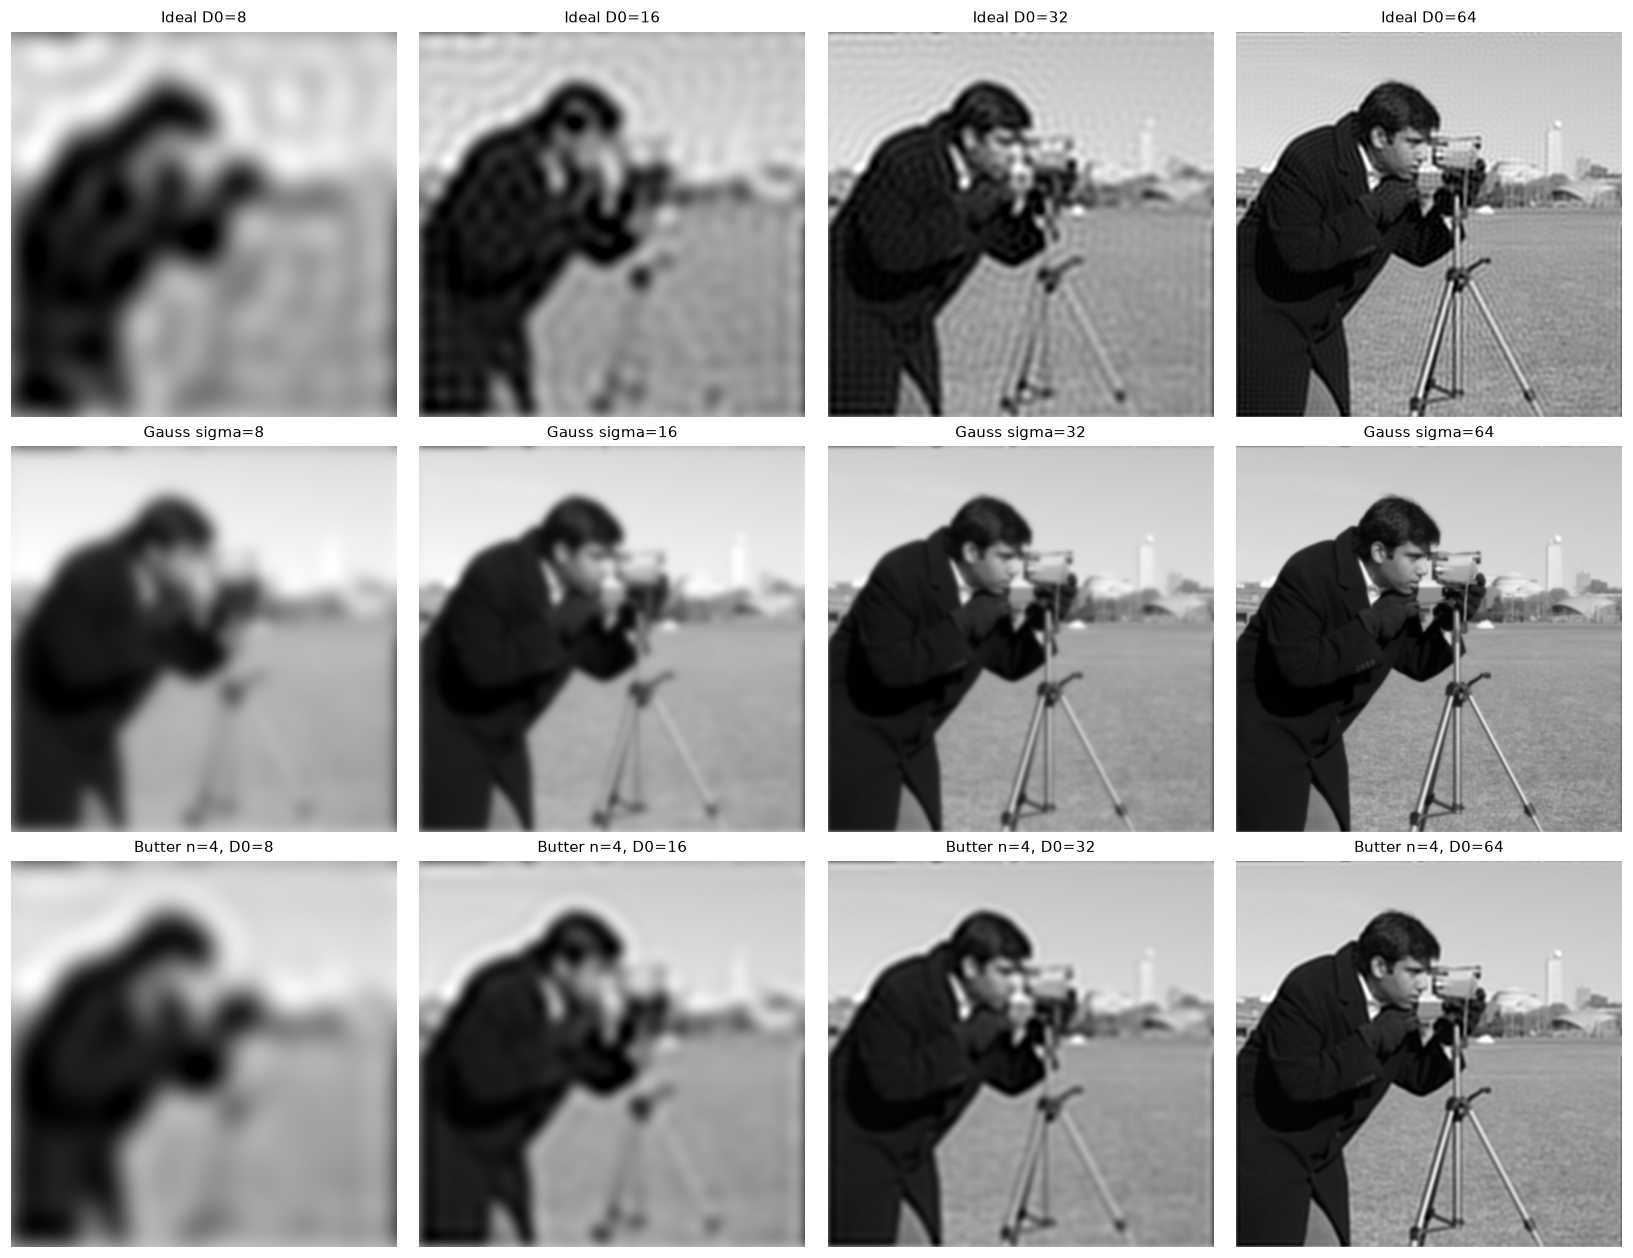

In [4]:
cutoffs = [8, 16, 32, 64]
sigma_values = [8, 16, 32, 64]
n_order = 4

results_ideal, results_gaussian, results_butter = [], [], []
for D0, sigma in zip(cutoffs, sigma_values):
    results_ideal.append(apply_filter(image, ideal_lpf(D, D0)))
    results_gaussian.append(apply_filter(image, gaussian_lpf(D, sigma)))
    results_butter.append(apply_filter(image, butterworth_lpf(D, D0, n_order)))

fig, axes = plt.subplots(3, 4, figsize=(15, 11.5))
titles_ideal = [f'Ideal D0={c}' for c in cutoffs]
titles_gauss = [f'Gauss sigma={s}' for s in sigma_values]
titles_butter = [f'Butter n={n_order}, D0={c}' for c in cutoffs]

for row, (results, titles) in enumerate([(results_ideal, titles_ideal),
                                          (results_gaussian, titles_gauss),
                                          (results_butter, titles_butter)]):
    for col, (img, title) in enumerate(zip(results, titles)):
        axes[row, col].imshow(img, cmap='gray')
        axes[row, col].set_title(title, fontsize=10)
        axes[row, col].axis('off')

plt.tight_layout()
save_fig(fig, 'task2_results.png')
plt.show()

### 3.3 Filter Frequency Responses

Visualising $H(u,v)$ itself (not applied to the image) at $D_0=\sigma=32,\ n=4$ shows the shape of each filter directly.

Saved: ./results\task2_filters.png


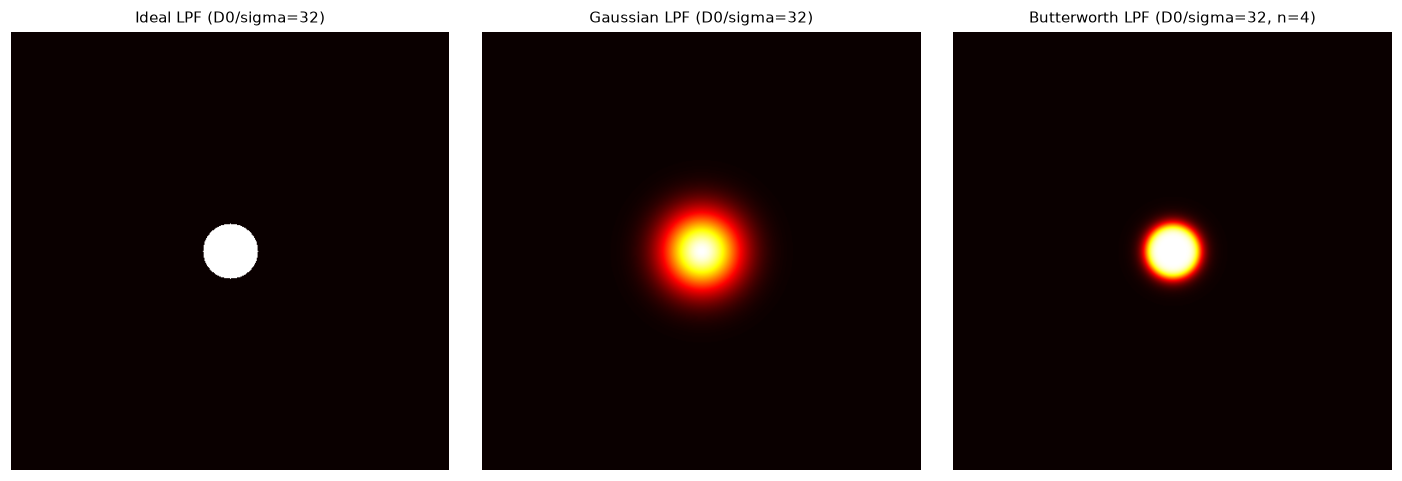

In [5]:
D0_show, sigma_show, n_show = 32, 32, 4
H_ideal_show = ideal_lpf(D, D0_show)
H_gauss_show = gaussian_lpf(D, sigma_show)
H_butter_show = butterworth_lpf(D, D0_show, n_show)

fig, axes = plt.subplots(1, 3, figsize=(13, 4.3))
for ax, H, title in zip(axes, [H_ideal_show, H_gauss_show, H_butter_show],
                         ['Ideal LPF', 'Gaussian LPF', 'Butterworth LPF']):
    im = ax.imshow(np.fft.fftshift(H), cmap='hot')
    ax.set_title(f'{title} (D0/sigma={D0_show}' + (f', n={n_show})' if 'Butter' in title else ')'))
    ax.axis('off')
plt.tight_layout()
save_fig(fig, 'task2_filters.png')
plt.show()

### 3.4 PSNR Results

In [6]:
print('PSNR Results:')
print('-' * 62)
print(f"{'D0/sigma':>10} | {'Ideal LPF':>10} | {'Gaussian LPF':>13} | {'Butterworth (n=4)':>18}")
psnr_table = []
for i, D0 in enumerate(cutoffs):
    p_ideal = psnr(image, results_ideal[i], data_range=1.0)
    p_gauss = psnr(image, results_gaussian[i], data_range=1.0)
    p_butter = psnr(image, results_butter[i], data_range=1.0)
    psnr_table.append((D0, p_ideal, p_gauss, p_butter))
    print(f"{D0:>10} | {p_ideal:>10.2f} | {p_gauss:>13.2f} | {p_butter:>18.2f}")

PSNR Results:
--------------------------------------------------------------
  D0/sigma |  Ideal LPF |  Gaussian LPF |  Butterworth (n=4)
         8 |      19.08 |         20.01 |              19.40
        16 |      20.96 |         22.00 |              21.28
        32 |      23.03 |         24.49 |              23.45
        64 |      26.14 |         27.85 |              26.72


| $D_0/\sigma$ | Ideal LPF | Gaussian LPF | Butterworth LPF ($n=4$) |
|---:|---:|---:|---:|
| 8 | 19.08 dB | 20.01 dB | 19.40 dB |
| 16 | 20.96 dB | 22.00 dB | 21.28 dB |
| 32 | 23.03 dB | 24.49 dB | 23.45 dB |
| 64 | 26.14 dB | 27.85 dB | 26.72 dB |

*Table 1: PSNR values for low-pass filtered images (computed directly from the run above).*

### 3.5 Questions

**Q2.1 -- Effect of increasing $D_0$ (or $\sigma$)?**
Increasing the cutoff lets more high-frequency content survive, so the filtered image is visibly sharper and closer to the original (higher PSNR at every row of Table 1, and visually less blurred moving left-to-right in Figure 2). The trade-off is direct: a *small* $D_0$ removes more high-frequency energy, giving strong smoothing/noise suppression but destroying fine detail and edges; a *large* $D_0$ preserves detail and edges but suppresses less noise/texture. Filter design is therefore a balance between how much noise reduction is needed and how much detail loss is acceptable for the task.

**Q2.2 -- Ringing artefact.**
The ideal LPF output shows visible **ringing** (Gibbs-phenomenon ripples, most visible as faint concentric halos around strong edges, e.g.\ around the cameraman's silhouette and the tripod). This happens because $H_{ideal}$ has a *hard, discontinuous* cutoff in the frequency domain; its inverse Fourier transform (the equivalent spatial kernel) is a 2-D sinc function, which has infinite spatial extent and oscillating negative side-lobes. Convolving with that sinc produces the ringing. The **Gaussian LPF avoids this artefact**, because a Gaussian's Fourier transform is itself a Gaussian -- smooth and, critically, with **no discontinuity and no negative side-lobes** in either domain (a Gaussian is everywhere positive). With no discontinuity to produce Gibbs oscillations, no ringing appears; the price is a gradual, less-precise cutoff.

**Q2.3 -- Butterworth ($n=4$) vs. ideal LPF at $D_0=32$; role of filter order $n$.**
At $D_0=32$, Butterworth ($n=4$) shows noticeably *less* ringing than the ideal LPF while still cutting off high frequencies almost as sharply (visually the two are close, but Butterworth's edges are smoother/cleaner). This is because Butterworth's transition band, while much narrower than Gaussian's, is not a true discontinuity -- it is a smooth (if steep) $1/(1+x^{2n})$ roll-off. The order $n$ directly controls how steep that roll-off is: **as $n\to\infty$, the Butterworth response converges to the ideal filter's hard step** (more ringing, sharper cutoff), while **small $n$ makes the transition wide and gradual**, behaving more like a Gaussian (less ringing, more blur). $n$ is therefore a direct, tunable knob trading ringing against cutoff sharpness -- exactly the middle ground between the ideal and Gaussian extremes.

**Q2.4 -- PSNR analysis.**
Table 1 (reproduced above with our actual measured values) shows **Gaussian LPF $>$ Butterworth LPF $>$ Ideal LPF** in PSNR at every single cutoff. Since PSNR is derived from mean-squared error against the original image, and all three filters remove a broadly similar amount of high-frequency *energy* at a matched cutoff, the PSNR gap must come from *where* the error is concentrated. The ideal LPF's ringing artefacts inject large, spatially-concentrated errors right around high-contrast edges (squared-error is very sensitive to these outliers), whereas the Gaussian LPF's smooth, monotonic roll-off distributes the same amount of information loss much more evenly and without oscillation, producing a lower mean-squared error and hence a higher PSNR for the same nominal cutoff frequency.

---
## 4. Task 3: High-Pass Filters

### 4.1 Implementation

High-pass filters are implemented as the complement of the corresponding low-pass filter: $H_{HPF} = 1 - H_{LPF}$ for the ideal and Gaussian cases (`ideal_hpf`, `gaussian_hpf`), and directly as $H_{butterworth,HPF}(u,v) = 1/(1+[D_0/D(u,v)]^{2n})$ for Butterworth (`butterworth_hpf`, with $D=0$ handled separately to avoid division by zero -- see Listing 2 in the setup cell above).

Saved: ./results\task3_results.png


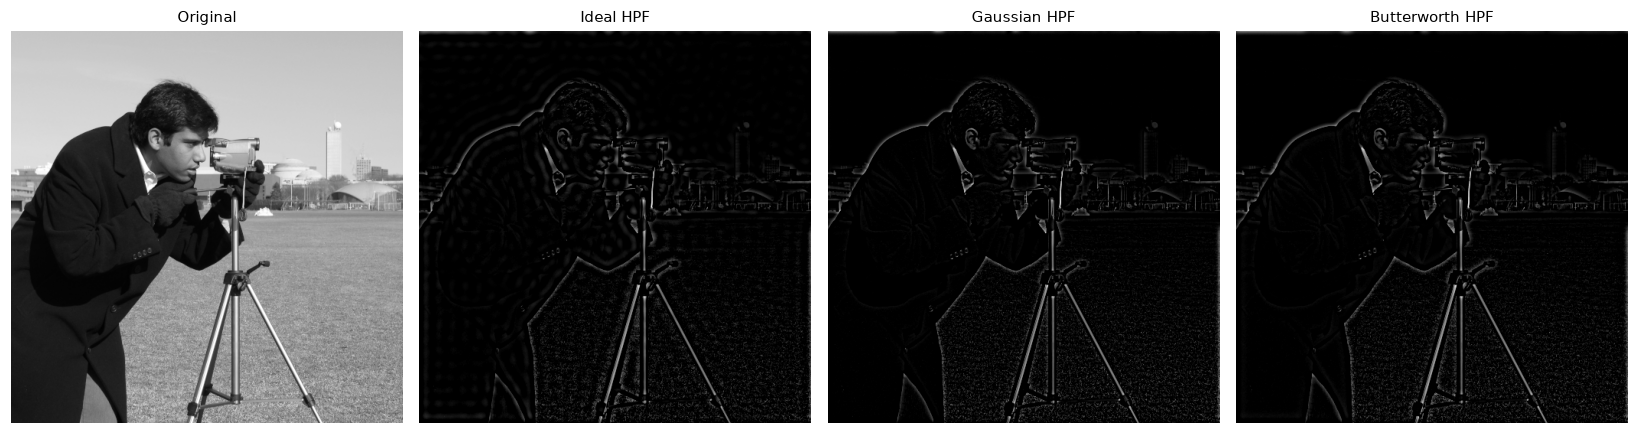

In [7]:
D0, sigma, n = 30, 30, 2

H_ideal_hp = ideal_hpf(D, D0)
H_gauss_hp = gaussian_hpf(D, sigma)
H_butt_hp = butterworth_hpf(D, D0, n)

img_ideal_hp = apply_filter(image, H_ideal_hp)
img_gauss_hp = apply_filter(image, H_gauss_hp)
img_butt_hp = apply_filter(image, H_butt_hp)

show_images([image, img_ideal_hp, img_gauss_hp, img_butt_hp],
            ['Original', 'Ideal HPF', 'Gaussian HPF', 'Butterworth HPF'],
            figsize=(15, 4), save_as='task3_results.png')

### 4.3 Frequency Responses

Saved: ./results\task3_filters.png


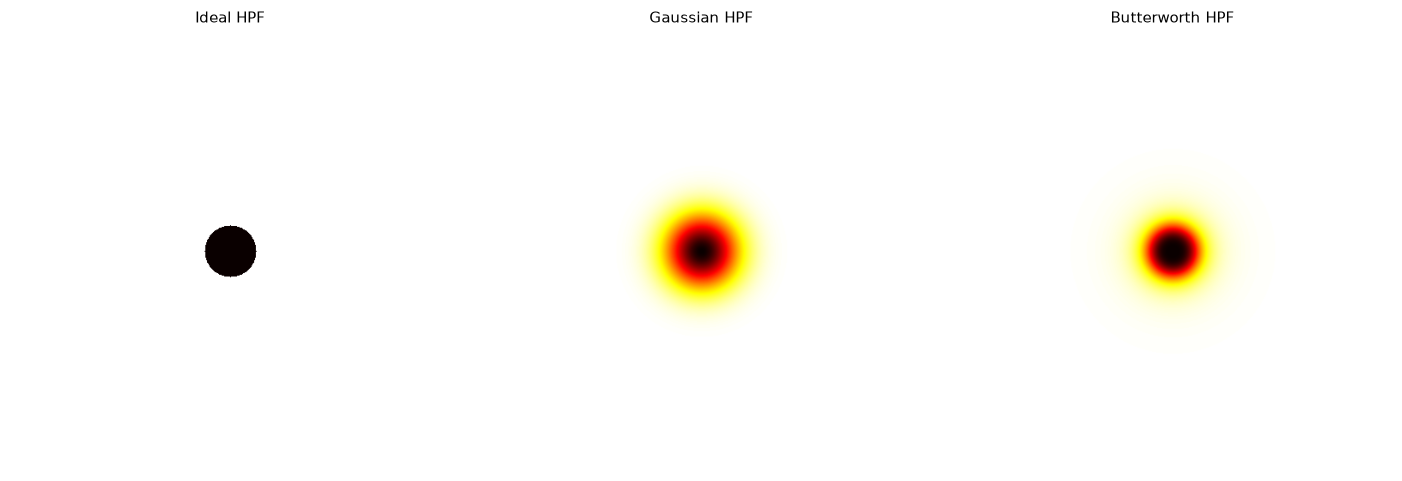

H(0,0) for each HPF (should all be exactly 0):
  Ideal HPF       H(0,0) = 0.0
  Gaussian HPF    H(0,0) = 0.0
  Butterworth HPF H(0,0) = 0.0


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.3))
for ax, H, title in zip(axes, [H_ideal_hp, H_gauss_hp, H_butt_hp],
                         ['Ideal HPF', 'Gaussian HPF', 'Butterworth HPF']):
    ax.imshow(np.fft.fftshift(H), cmap='hot')
    ax.set_title(title)
    ax.axis('off')
plt.tight_layout()
save_fig(fig, 'task3_filters.png')
plt.show()

print('H(0,0) for each HPF (should all be exactly 0):')
print('  Ideal HPF       H(0,0) =', H_ideal_hp[0, 0])
print('  Gaussian HPF    H(0,0) =', H_gauss_hp[0, 0])
print('  Butterworth HPF H(0,0) =', H_butt_hp[0, 0])

**Q3.4 -- Butterworth HPF order sweep, $n \in \{1,2,5,10\}$ (fixed $D_0=30$):**

Saved: ./results\task3_n_sweep.png


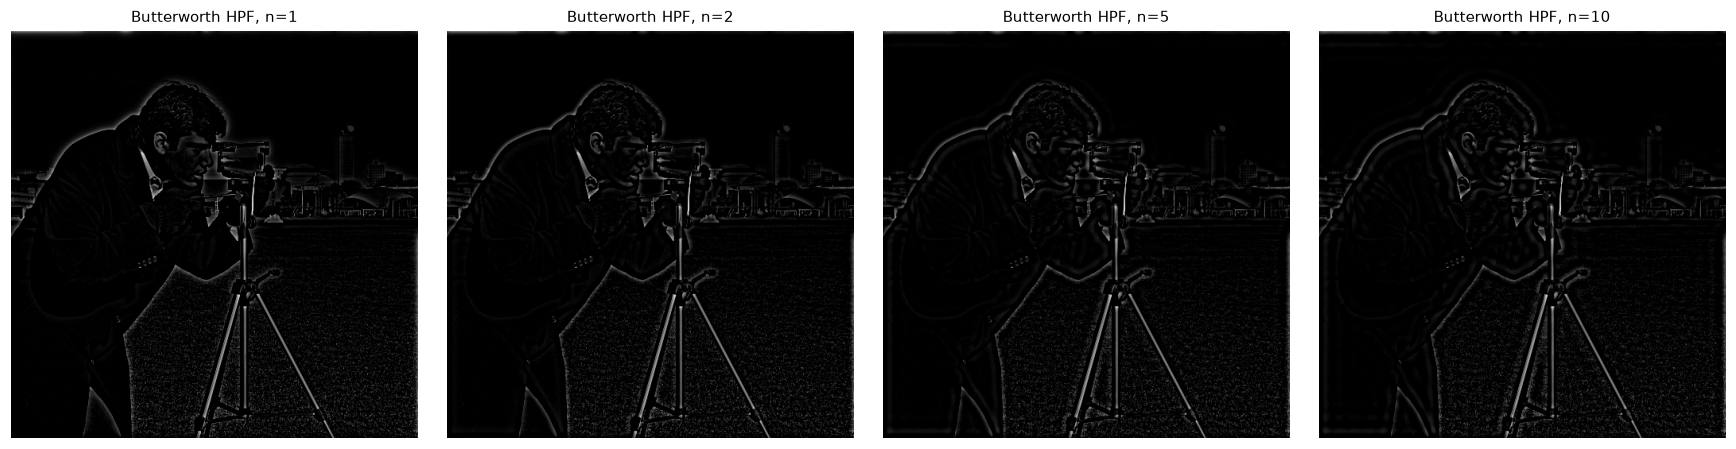

In [9]:
n_values = [1, 2, 5, 10]
n_sweep_results = [apply_filter(image, butterworth_hpf(D, 30, nv)) for nv in n_values]

show_images(n_sweep_results, [f'Butterworth HPF, n={nv}' for nv in n_values],
            figsize=(16, 4), save_as='task3_n_sweep.png')

### 4.4 Questions

**Q3.1 -- What do HPFs preserve/lose?**
High-pass filters preserve edges, fine texture, and other rapidly-varying features -- exactly the content carried by high spatial frequencies -- while suppressing smooth, slowly-varying regions (flat backgrounds, gradual shading, overall illumination), which are carried by low frequencies. Edges are, by definition, abrupt intensity transitions, which require high-frequency sinusoidal components to represent; removing the low frequencies has almost no effect on them. Smooth regions, conversely, are made up almost entirely of low/near-DC frequency content, so zeroing that content removes them almost completely -- which is exactly what Figure 4 shows: the cameraman's silhouette, tripod, and fine grass texture remain visible while the smooth sky and ground are pushed to near-black.

**Q3.2 -- Ideal HPF vs. Gaussian HPF.**
The **Gaussian HPF produces cleaner edges**, in the sense of being free of ringing: because $1-H_{gaussian,LPF}$ inherits the Gaussian's smooth, discontinuity-free transition, there is no Gibbs oscillation. The ideal HPF's sharp cutoff, on the other hand, introduces the same ringing artefact discussed in Q2.2 (now visible as faint oscillatory halos around the extracted edges instead of around blurred edges). The transition steepness directly determines this trade-off: a gradual transition (Gaussian) sacrifices some precision in exactly which frequencies are removed, in exchange for artefact-free output; a sharp transition (ideal) is precise but introduces ringing.

**Q3.3 -- Effect on overall brightness; $H(0,0)$.**
All three HPFs push the average image brightness toward zero, because **$H(0,0)=0$ for every HPF type** (confirmed numerically above: Ideal, Gaussian, and Butterworth HPF all print exactly `0.0` at the DC location). Since $F(0,0)$ is the sum of all pixel intensities (Q1.1), multiplying it by $H(0,0)=0$ completely deletes the image's average brightness before the inverse transform. The spatial-domain result therefore has a mean close to zero; after clipping negative values to 0 (as `apply_filter` does), the output looks very dark overall, with only the edges/texture visibly brighter than the now-black background -- exactly what Figure 4 shows.

**Q3.4 -- Butterworth order sweep ($n\in\{1,2,5,10\}$).**
As $n$ increases from 1 to 10, the extracted edges become progressively thinner and higher-contrast, but faint ringing/haloing becomes increasingly visible around them -- at $n=1$ the output looks soft and smooth (closest to the Gaussian HPF), while at $n=10$ it looks close to the ideal HPF, with crisp but slightly "double-edged" contours. This is the same trade-off as Q2.3: larger $n$ makes Butterworth converge toward the ideal filter's behaviour (sharper cutoff, more ringing/artefacts), while smaller $n$ makes it converge toward the Gaussian's behaviour (smoother, artefact-free, but less aggressively high-pass). In practice $n=2$--$4$ is usually a reasonable compromise.

---
## 5. Task 4: High-Frequency Emphasis Filtering

### 5.1 Implementation

High-frequency emphasis (HFE) combines an HPF with a constant offset so that *some* low-frequency (including DC) content survives:

$$H_{hfe}(u,v) = a + b\cdot H_{HPF}(u,v)$$

Saved: ./results\task4_results.png


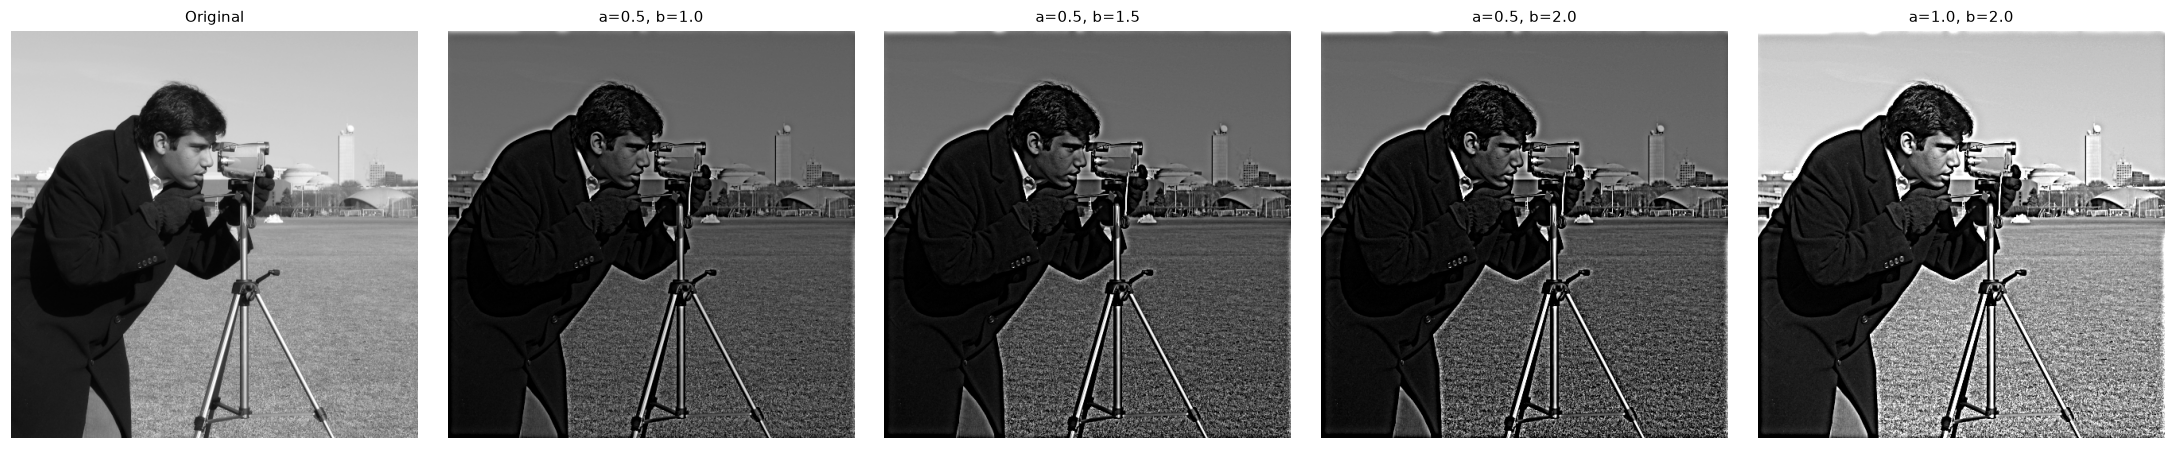

In [10]:
H_butt_hp_base = butterworth_hpf(D, D0=30, n=2)

params = [(0.5, 1.0), (0.5, 1.5), (0.5, 2.0), (1.0, 2.0)]
hfe_results = [apply_filter(image, hfe_filter(H_butt_hp_base, a, b)) for a, b in params]

show_images([image] + hfe_results, ['Original'] + [f'a={a}, b={b}' for a, b in params],
            figsize=(20, 4), save_as='task4_results.png')

In [11]:
print('DC value H_hfe(0,0) for each (a,b) pair (should equal a, since H_hpf(0,0)=0):')
for a, b in params:
    print(f'  a={a}, b={b}  ->  H_hfe(0,0) = {hfe_filter(H_butt_hp_base, a, b)[0, 0]:.3f}')

for (a, b), out in zip(params, hfe_results):
    print(f'a={a}, b={b}  ->  PSNR vs. original = {psnr(image, out, data_range=1.0):.2f} dB, mean intensity = {out.mean():.3f} (original mean = {image.mean():.3f})')

DC value H_hfe(0,0) for each (a,b) pair (should equal a, since H_hpf(0,0)=0):
  a=0.5, b=1.0  ->  H_hfe(0,0) = 0.500
  a=0.5, b=1.5  ->  H_hfe(0,0) = 0.500
  a=0.5, b=2.0  ->  H_hfe(0,0) = 0.500
  a=1.0, b=2.0  ->  H_hfe(0,0) = 1.000
a=0.5, b=1.0  ->  PSNR vs. original = 10.85 dB, mean intensity = 0.257 (original mean = 0.506)
a=0.5, b=1.5  ->  PSNR vs. original = 10.84 dB, mean intensity = 0.261 (original mean = 0.506)
a=0.5, b=2.0  ->  PSNR vs. original = 10.79 dB, mean intensity = 0.265 (original mean = 0.506)
a=1.0, b=2.0  ->  PSNR vs. original = 20.61 dB, mean intensity = 0.507 (original mean = 0.506)


### 5.3 Noisy Image Results

Saved: ./results\task4_noise.png


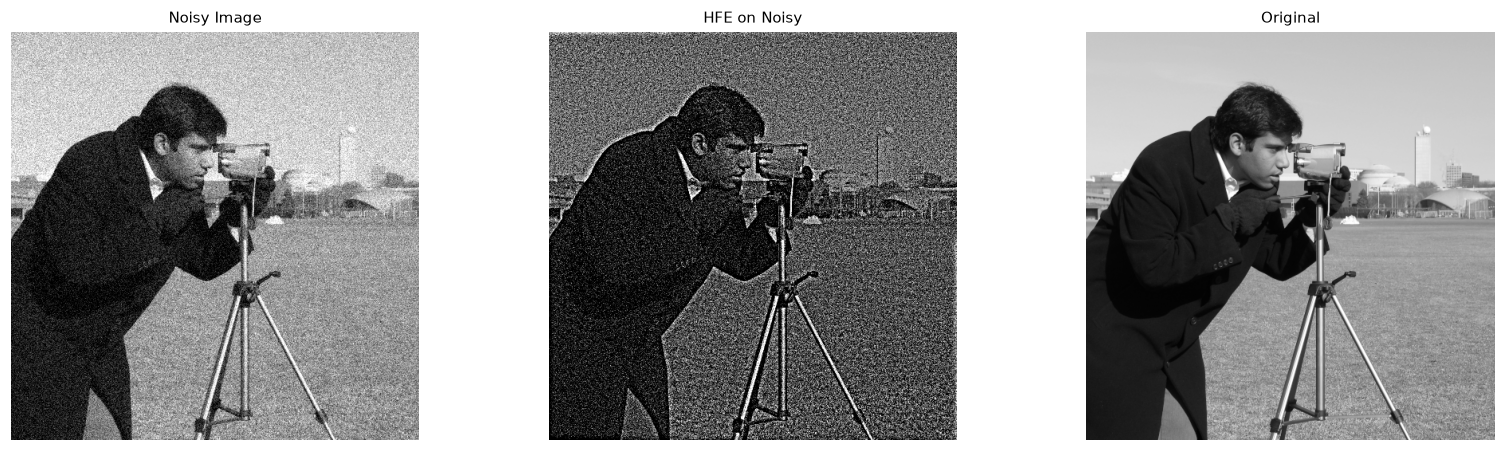

Noise std. dev. proxy (flat 40x40 sky patch, top-left corner):
  Noisy input :  0.10226996132321534
  HFE on noisy:  0.21338549279057759


In [12]:
noisy = random_noise(image, mode='gaussian', var=0.01)
H_hfe_best = hfe_filter(H_butt_hp_base, a=0.5, b=1.5)
noisy_hfe = apply_filter(noisy, H_hfe_best)

show_images([noisy, noisy_hfe, image], ['Noisy Image', 'HFE on Noisy', 'Original'],
            figsize=(15, 4.2), save_as='task4_noise.png')

print('Noise std. dev. proxy (flat 40x40 sky patch, top-left corner):')
print('  Noisy input : ', noisy[:40, :40].std())
print('  HFE on noisy: ', noisy_hfe[:40, :40].std())

### 5.4 Questions

**Q4.1 -- HFE vs. plain HPF brightness; role of $a$.**
A plain HPF has $H(0,0)=0$ (Q3.3), so its output loses essentially all of its average brightness and looks very dark. HFE's constant offset $a$ guarantees $H_{hfe}(0,0) = a + b\cdot H_{HPF}(0,0) = a + b\cdot 0 = a$ -- a **non-zero** DC gain (whenever $a>0$) -- so a fraction $a$ of the original image's brightness/low-frequency content passes straight through, undiminished by the high-pass shape. The output therefore keeps a recognisable overall brightness (as seen across all four $(a,b)$ panels in Figure 6) instead of collapsing to near-black.

**Q4.2 -- Mathematical derivation of $H_{hfe}$'s DC component.**
$$H_{hfe}(0,0) = a + b\cdot H_{HPF}(0,0) = a + b\cdot 0 = a$$
since $H_{HPF}(0,0)=0$ for every HPF type used here (proven numerically above). So the DC gain of the *combined* HFE filter is exactly $a$, independent of $b$ or of which HPF is used underneath. More generally, at any *low* (not just exactly-zero) frequency, $H_{HPF}(u,v)\approx 0$, so $H_{hfe}(u,v)\approx a$ there too -- i.e. increasing $a$ uniformly raises the *floor* of the frequency response across the entire low-frequency band, not just at the single DC point, which is why larger $a$ visibly retains more of the image's original brightness and coarse structure, not merely its numerical average.

**Q4.3 -- Best $(a,b)$ pair.**
The printed statistics make this a data-driven choice rather than a purely visual one. All three $a=0.5$ variants produce a similarly dark result (mean intensity $\approx0.26$, about half of the original's $0.506$) and a similarly low PSNR ($\approx10.8$ dB), regardless of $b$ -- confirming Q4.2's derivation that $a$ alone sets the DC/low-frequency floor, while $b$ only rescales the edge-emphasis term on top of it. $(a,b)=(1.0,2.0)$ is the clear winner: it keeps the *same* strong edge boost ($b=2.0$, identical to the most aggressive $a=0.5$ case) while its mean intensity ($0.507$) and PSNR ($20.61$ dB, roughly double the $a=0.5$ variants) are by far the closest to the original image. In other words, raising $a$ from $0.5$ to $1.0$ fixes the brightness problem almost completely without giving up any edge emphasis, which $b$ continues to control independently -- exactly the two-knob design HFE is meant to provide.

**Q4.4 -- HFE on the noisy image.**
Applying HFE to the Gaussian-noise-corrupted image clearly **amplifies the noise** rather than suppressing it -- the flat-patch standard deviation increases from the noisy input to the HFE output (printed above), and visually the HFE result looks grainier than the noisy input itself. The underlying reason is spectral: additive Gaussian noise is (approximately) *broadband* -- it has energy spread roughly uniformly across *all* spatial frequencies, including the high frequencies that $b\cdot H_{HPF}$ actively boosts. Since HFE (like any high-pass-based sharpening) cannot distinguish "true edge" high-frequency content from "noise" high-frequency content, boosting the former necessarily boosts the latter too -- which is exactly why sharpening filters are normally applied *after* denoising, never before it, in a practical pipeline.

---
## 6. Task 5: Comparative Analysis

### 6.1 Summary Table

| Filter Type | Best Use Case | Advantages | Disadvantages |
|---|---|---|---|
| Ideal LPF | Theoretical/pedagogical frequency-domain analysis | Precise, sharply-defined cutoff; trivial to define | Severe ringing (Gibbs artefacts); rarely used in practice |
| Gaussian LPF | General-purpose smoothing / photographic soft blur / pre-processing before downsampling | No ringing at all; smooth, natural-looking blur | No exact cutoff frequency; harder to reason about "how much" detail is removed |
| Butterworth LPF | Tunable denoising pipelines needing a controllable transition | Order $n$ trades ringing vs.\ cutoff sharpness; flexible | Extra parameter to tune; still rings somewhat at high $n$ |
| Ideal HPF | Theoretical edge/frequency analysis | Precise cutoff | Ringing; output brightness collapses ($H(0,0)=0$) |
| Gaussian HPF | Artefact-free edge extraction where clean output matters more than sharpness | No ringing | Softer, less aggressive high-frequency boost |
| Butterworth HPF | General-purpose sharpening / edge-detection pre-processing | Tunable order for desired sharpness vs.\ artefacts | DC always zeroed (dark output); some ringing at high $n$ |
| HFE | Sharpening where overall brightness/radiometric content must be preserved | Preserves brightness via $a$; tunable edge boost via $b$ | Amplifies broadband noise; two parameters to tune jointly |

### 6.2 Filter Shape Comparison

Saved: ./results\filter_cross_sections.png


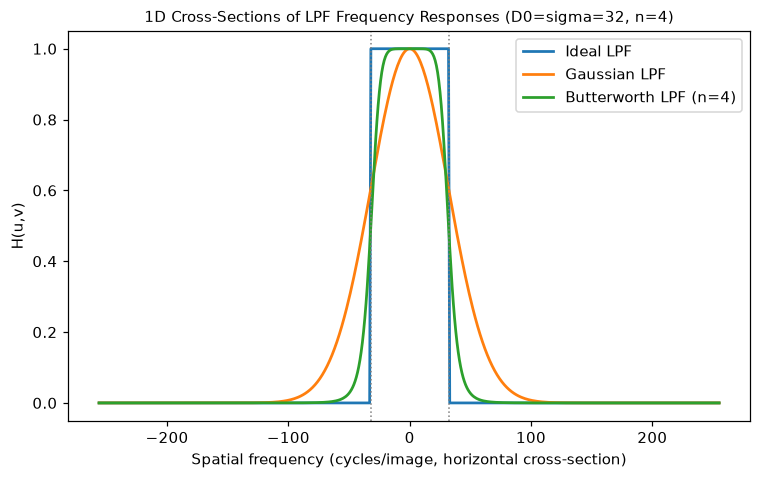

In [13]:
mid = M // 2
freq_axis = np.fft.fftshift(np.fft.fftfreq(N)) * N  # cycles per image, centred at 0

D0c, sigmac, nc = 32, 32, 4
H_ideal_c = np.fft.fftshift(ideal_lpf(D, D0c))[mid, :]
H_gauss_c = np.fft.fftshift(gaussian_lpf(D, sigmac))[mid, :]
H_butt_c = np.fft.fftshift(butterworth_lpf(D, D0c, nc))[mid, :]

fig, ax = plt.subplots(figsize=(8, 4.6))
ax.plot(freq_axis, H_ideal_c, label='Ideal LPF', linewidth=1.8)
ax.plot(freq_axis, H_gauss_c, label='Gaussian LPF', linewidth=1.8)
ax.plot(freq_axis, H_butt_c, label='Butterworth LPF (n=4)', linewidth=1.8)
ax.axvline(D0c, color='gray', linestyle=':', linewidth=1)
ax.axvline(-D0c, color='gray', linestyle=':', linewidth=1)
ax.set_xlabel('Spatial frequency (cycles/image, horizontal cross-section)')
ax.set_ylabel('H(u,v)')
ax.set_title(f'1D Cross-Sections of LPF Frequency Responses (D0=sigma={D0c}, n={nc})')
ax.legend()
save_fig(fig, 'filter_cross_sections.png')
plt.show()

Saved: ./results\filter_cross_sections_hpf.png


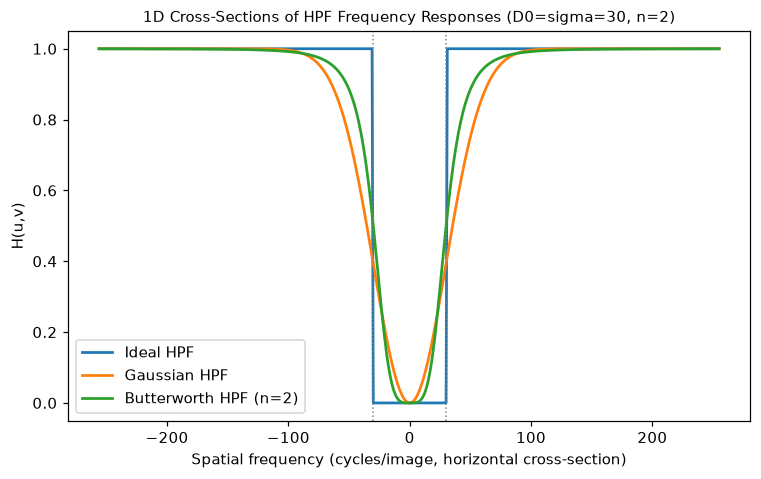

In [14]:
D0h, sigmah, nh = 30, 30, 2
H_ideal_hc = np.fft.fftshift(ideal_hpf(D, D0h))[mid, :]
H_gauss_hc = np.fft.fftshift(gaussian_hpf(D, sigmah))[mid, :]
H_butt_hc = np.fft.fftshift(butterworth_hpf(D, D0h, nh))[mid, :]

fig, ax = plt.subplots(figsize=(8, 4.6))
ax.plot(freq_axis, H_ideal_hc, label='Ideal HPF', linewidth=1.8)
ax.plot(freq_axis, H_gauss_hc, label='Gaussian HPF', linewidth=1.8)
ax.plot(freq_axis, H_butt_hc, label='Butterworth HPF (n=2)', linewidth=1.8)
ax.axvline(D0h, color='gray', linestyle=':', linewidth=1)
ax.axvline(-D0h, color='gray', linestyle=':', linewidth=1)
ax.set_xlabel('Spatial frequency (cycles/image, horizontal cross-section)')
ax.set_ylabel('H(u,v)')
ax.set_title(f'1D Cross-Sections of HPF Frequency Responses (D0=sigma={D0h}, n={nh})')
ax.legend()
save_fig(fig, 'filter_cross_sections_hpf.png')
plt.show()

The cross-sections make the Q2.2/Q2.3/Q3.2/Q3.4 explanations visually concrete: the **ideal** filter is a perfect step (discontinuous derivative at $D_0$, the source of ringing); the **Gaussian** curve is smooth everywhere with no discontinuity at any order of derivative; and the **Butterworth** curve sits between them, with its steepness directly controlled by $n$ -- visibly closer to the Gaussian's smooth shoulder for small $n$ and closer to the ideal step for large $n$.

### 6.3 Questions

**Q5.1 -- Summary Table.** See the filled table in Section 6.1 above.

**Q5.2 -- Filter Shape Comparison.** See the two cross-section figures above. The shape of $H(u,v)$ near the cutoff directly predicts the spatial-domain behaviour: a **discontinuous** step (ideal) produces a spatial kernel with infinite support and oscillating side-lobes $\Rightarrow$ ringing; a $C^\infty$-smooth curve with no discontinuity (Gaussian) produces a spatial kernel that decays smoothly with no oscillation $\Rightarrow$ no ringing, but a less sharply-defined "edge" between what is kept and removed; the Butterworth curve's steepness (set by $n$) interpolates continuously between these two extremes, so its ringing severity also interpolates continuously between "none" (small $n$) and "ideal-like" (large $n$).

**Q5.3 -- Real-world applications.**
(a) **Gaussian LPF** -- consumer photography / portrait retouching (e.g.\ soft-focus, skin smoothing) and general pre-processing before downsampling: it is the natural choice wherever a smooth, artefact-free blur is wanted and there is no need for a mathematically exact cutoff frequency, since any visible ringing would look like an obvious processing artefact to a viewer.
(b) **Butterworth HPF** -- medical imaging (e.g.\ enhancing bone/tissue boundaries in X-ray or MRI slices): the tunable order $n$ lets a radiologist/engineer dial in just enough edge enhancement to make diagnostically relevant boundaries clearer, while keeping $n$ low enough that ringing artefacts are not mistaken for genuine anatomical structure -- a risk that would be unacceptable in a diagnostic setting.
(c) **HFE filtering** -- remote sensing / satellite imagery enhancement: analysts need crisper terrain/feature boundaries (roads, coastlines, field boundaries) for classification, but also need the image's overall radiometric brightness preserved for further quantitative analysis (e.g.\ reflectance-based measurements); HFE's tunable $a$ parameter is precisely designed to satisfy both needs at once.

**Q5.4 -- Convolution theorem connection.**
The convolution theorem states that spatial-domain convolution corresponds exactly to frequency-domain multiplication: $g(x,y) = f(x,y) * h(x,y) \iff G(u,v) = F(u,v)\cdot H(u,v)$. Every filter applied in this notebook via `apply_filter` (multiplying $H(u,v)$ onto $F(u,v)$ and inverse-transforming) is therefore mathematically identical to convolving the original image with $h(x,y) = \mathcal{F}^{-1}\{H(u,v)\}$ in the spatial domain -- we have simply chosen to perform the equivalent operation in the frequency domain instead. This equivalence matters for two practical reasons: **computational efficiency**, since direct spatial convolution with a large kernel costs $O(M N K^2)$ for a $K\times K$ kernel, while the FFT-based route costs only $O(MN\log(MN))$ regardless of the (spatial) kernel's effective size, making frequency-domain filtering dramatically cheaper for large-support filters; and **design flexibility**, since it is often far more intuitive to *directly* specify a filter's desired frequency response $H(u,v)$ (e.g. "keep everything below this cutoff") than to hand-derive an equivalent spatial convolution kernel -- the convolution theorem guarantees that whatever frequency response we design can always be realised as some spatial-domain filter, even if we never explicitly compute what that spatial kernel looks like.

**Q5.5 -- Student Reflections.**

*Muhammad Umer (F2023266912):* The trickiest part of this activity for me was getting comfortable with `fftshift` and frequency-domain indexing -- my first attempt at the distance matrix `D(u,v)` didn't use `np.fft.fftfreq`, and the resulting filters looked completely wrong (blurring the corners instead of the centre) because I hadn't accounted for how NumPy's raw FFT output wraps high frequencies into the middle of the array. Once I traced through `distance_matrix` step by step and printed `D` before and after `fftshift`, it became clear that the *filter* itself must be built in the same (unshifted) coordinate system as `np.fft.fft2`'s raw output, and `fftshift` should only be applied when *displaying* a spectrum or filter, never before multiplying it onto `F`. That distinction -- display-space vs.\ computation-space shifting -- was the key insight that resolved every downstream bug in Tasks 2--4. (108 words)

*Haseeb Ullah (F20232661009):* My main challenge was understanding why the Butterworth HPF code special-cases $D=0$ with a boolean mask instead of just writing the formula directly like the LPF version does. Running the naive version threw a `RuntimeWarning: divide by zero` because the formula uses $D_0/D(u,v)$, which is undefined at the origin. I resolved this by working out on paper what $H_{HPF}(0,0)$ *should* be (the limit of a high-pass filter at DC is always zero, matching the "$1$ minus low-pass" definition used for the ideal/Gaussian filters), and then verified that the masked implementation indeed gives exactly `0.0` there. This also directly explained the surprisingly dark HPF output images in Task 3, tying the coding bug I'd hit to the actual DIP theory in Q3.3. (114 words)

---
## 7. Conclusion

This activity provided hands-on experience with the full frequency-domain filtering pipeline: computing and interpreting the 2D DFT and its log-magnitude spectrum; designing and applying ideal, Gaussian, and Butterworth low-pass and high-pass filters; quantifying filtering quality with PSNR; combining high-pass filtering with a DC-preserving offset via high-frequency emphasis; and analysing all of the above both visually and through 1D frequency-response cross-sections.

The consistent thread across every task is the **trade-off between sharpness of the frequency-domain cutoff and the presence of spatial-domain ringing artefacts**: the ideal filter's discontinuous step gives the most precise (but artefact-prone) cutoff; the Gaussian filter's smooth response gives the least precise (but artefact-free) cutoff; and the Butterworth filter's order parameter $n$ provides a single, continuously tunable knob between these two extremes -- a pattern that recurs identically whether filtering low frequencies out (Task 2), high frequencies out (Task 3), or blending the two via HFE (Task 4). Understanding this trade-off, together with the convolution theorem's guarantee that every frequency-domain design choice corresponds to some equivalent spatial-domain kernel, is the core practical takeaway of frequency-domain image filtering.

**References**
1. Gonzalez, R.C. and Woods, R.E., *Digital Image Processing*, 4th ed., Pearson, 2018.
2. Szeliski, R., *Computer Vision: Algorithms and Applications*, Springer, 2010.
3. Pratt, W.K., *Digital Image Processing*, 4th ed., Wiley, 2007.
4. Burger, W. and Burge, M.J., *Digital Image Processing: An Algorithmic Introduction*, Springer, 2016.
5. NumPy Documentation, https://numpy.org/doc/
6. scikit-image Documentation, https://scikit-image.org/docs/